# MathNet CNN Math Problem Detection & Understanding
Uses the `ShadenA/MathNet` dataset with a CNN-based classifier to categorize math problems by topic.

## 1. Install Dependencies

In [16]:
!pip install tensorflow keras matplotlib scikit-learn seaborn pandas numpy pyarrow

## 2. Load the Dataset

In [17]:
import os

if not os.path.exists("MathNet"):
    !git lfs install
    !git clone https://huggingface.co/datasets/ShadenA/MathNet
    print("MathNet cloned successfully.")
else:
    print("MathNet directory already exists — skipping clone.")

MathNet directory already exists — skipping clone.


In [18]:
import pandas as pd
import glob
import os
import io
from PIL import Image
from concurrent.futures import ThreadPoolExecutor

files = sorted(glob.glob("MathNet/data/all/train-*.parquet"))
N_WORKERS = min(os.cpu_count(), len(files))
print(f"Loading {len(files)} parquet files with {N_WORKERS} workers...")

with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    dfs = list(pool.map(pd.read_parquet, files))

df_full = pd.concat(dfs, ignore_index=True)
print(f"Total rows loaded: {len(df_full):,}")
print("Columns:", df_full.columns.tolist())

# Scan every row to find those with at least one decodable image
def has_valid_image(imgs):
    if not isinstance(imgs, list) or len(imgs) == 0:
        return False
    for entry in imgs:
        if entry is not None and isinstance(entry, dict) and entry.get("bytes"):
            try:
                Image.open(io.BytesIO(entry["bytes"]))
                return True
            except Exception:
                pass
    return False

print("\nScanning for rows with valid images across all countries (may take ~1–2 min)...")
image_mask = df_full["images"].apply(has_valid_image)
df_train = df_full[image_mask].reset_index(drop=True)

print(f"\nRows with valid images: {len(df_train):,} / {len(df_full):,}")

if len(df_train) == 0:
    print("\nWARNING: No rows with valid images found.")
    print("This usually means git-lfs image data was not downloaded.")
    print("Image models (EfficientNetB0, MobileNetV2) will be skipped.")
    print("The text-based 1D CNN will still train on the full dataset.\n")
    print("Example row from full dataset:")
    print(df_full.iloc[0])
else:
    print("\nBreakdown by country:")
    print(df_train["country"].value_counts().to_string())
    print("\nExample entry:")
    print(df_train.iloc[0])


Loading 56 parquet files with 2 workers...
Total rows loaded: 27,817
Columns: ['id', 'problem_markdown', 'solutions_markdown', 'images', 'country', 'competition', 'topics_flat', 'language', 'problem_type', 'final_answer']

Scanning for rows with valid images across all countries (may take ~1–2 min)...

Rows with valid images: 0 / 27,817

This usually means git-lfs image data was not downloaded.
Image models (EfficientNetB0, MobileNetV2) will be skipped.
The text-based 1D CNN will still train on the full dataset.

Example row from full dataset:
id                                                                 009s
problem_markdown      Each cell of an $n \times n$ grid square is co...
solutions_markdown    [Color row 1 black and rows 2, 3 white. Then e...
images                [{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...
country                                                       Argentina
competition                                            NATIONAL XXX OMA
topics_flat       

In [19]:
# import matplotlib.pyplot as plt

# if "country" in df_train.columns:
#     country_counts = df_train["country"].value_counts()
#     print("Rows per country:")
#     print(country_counts.to_string())

#     plt.figure(figsize=(10, 4))
#     country_counts.plot(kind="bar", color="steelblue")
#     plt.title("Training samples by country (top 10)")
#     plt.xlabel("Country")
#     plt.ylabel("Number of rows")
#     plt.xticks(rotation=45, ha="right")
#     plt.tight_layout()
#     plt.show()
# else:
#     print("No 'country' column in dataset.")

## 3. Explore the Dataset

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Columns:", df_train.columns.tolist())
print("Shape:", df_train.shape)
df_train.head()

Columns: ['id', 'problem_markdown', 'solutions_markdown', 'images', 'country', 'competition', 'topics_flat', 'language', 'problem_type', 'final_answer']
Shape: (0, 10)


,id,problem_markdown,solutions_markdown,images,country,competition,topics_flat,language,problem_type,final_answer


Using label column: topics_flat
Source: 27,817 rows
Counted 11 unique top-level categories.


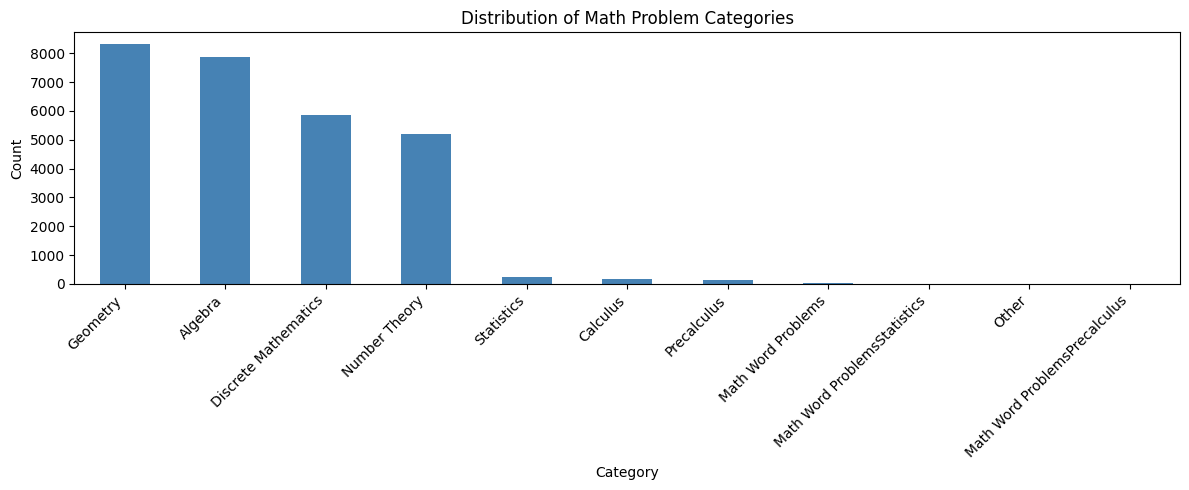

In [21]:
import os
import ast
import matplotlib.pyplot as plt

label_col = "topics_flat"
print("Using label column:", label_col)

# Use df_full so this works even when no images are available (df_train may be empty)
source_df = df_full if len(df_full) > 0 else df_train
print(f"Source: {len(source_df):,} rows")

def get_top_category(val):
    try:
        topics = val if isinstance(val, list) else ast.literal_eval(str(val))
        if topics:
            return topics[0].split(">")[0].strip()
    except Exception:
        pass
    return "Other"

label_counts = source_df[label_col].apply(get_top_category).value_counts().sort_values(ascending=False)
print(f"Counted {len(label_counts)} unique top-level categories.")

if len(label_counts) == 0:
    print("No label data found — skipping plot.")
else:
    plt.figure(figsize=(12, 5))
    label_counts.plot(kind="bar", color="steelblue")
    plt.title("Distribution of Math Problem Categories")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 4. Preprocess â€” Tokenise Text for 1-D CNN

In [ ]:
import ast
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tf_keras.preprocessing.text import Tokenizer
from tf_keras.preprocessing.sequence import pad_sequences

text_col = "problem_markdown"
print("Text column:", text_col, "| Label column:", label_col)

# Use the full dataset for text classification
df_text = df_full.dropna(subset=[text_col, label_col]).reset_index(drop=True)
print(f"Using full dataset: {len(df_text):,} rows")

# Keep only the 4 well-represented classes (each with 5000+ examples).
# Statistics, Calculus, Precalculus, and Math Word Problems together have < 600
# examples total — too few for a CNN to learn reliably — so they are dropped.
CATEGORY_MAP = {
    "Algebra":              "Algebra",
    "Number Theory":        "Number Theory",
    "Geometry":             "Geometry",
    "Trigonometry":         "Geometry",
    "Discrete Mathematics": "Combinatorics",
    "Combinatorics":        "Combinatorics",
}

def extract_top_label(topics_raw):
    try:
        topics = topics_raw if isinstance(topics_raw, list) else ast.literal_eval(str(topics_raw))
        if topics:
            top = topics[0].split(">")[0].strip()
            return CATEGORY_MAP.get(top)  # None for unmapped topics
    except Exception:
        pass
    return None

df_text["label"] = df_text[label_col].apply(extract_top_label)

before = len(df_text)
df_text = df_text[df_text["label"].notna()].reset_index(drop=True)
print(f"Dropped {before - len(df_text):,} rows with rare/unmapped classes → {len(df_text):,} remain")

print("Category distribution:")
print(df_text["label"].value_counts().to_string())

le = LabelEncoder()
y_all = le.fit_transform(df_text["label"])
num_classes = len(le.classes_)
print(f"Classes ({num_classes}):", le.classes_)

MAX_WORDS = 20_000
MAX_LEN   = 256

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df_text[text_col].astype(str))

X_all = pad_sequences(
    tokenizer.texts_to_sequences(df_text[text_col].astype(str)),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)
print("X shape:", X_all.shape, "| y shape:", y_all.shape)

## 5. Train / Validation Split

In [22]:
from sklearn.model_selection import train_test_split
import numpy as np

class_counts = np.bincount(y_all)

if class_counts.min() >= 2:
    stratify_labels = y_all
    print("Using stratified split.")
else:
    stratify_labels = None
    print("Some classes have only 1 example, so using a regular random split.")

X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels,
)
print("Train:", X_train.shape, "| Val:", X_val.shape)

Using stratified split.
Train: (22253, 256) | Val: (5564, 256)


## 5a. Image Data Preparation
The dataset includes problem figures stored as raw bytes. We decode each problem's first image, resize it to 224 × 224 (the standard ImageNet input size), and create a train/val split aligned with the text split.

In [23]:
import io
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split as _tts
from concurrent.futures import ThreadPoolExecutor

IMG_SIZE = 224

if len(df_train) == 0:
    print("No valid images available — skipping image data preparation.")
    print("Image models in sections 5b and 5c will also be skipped.")
    X_img_train = X_img_val = None
else:
    # df_train is already filtered to rows with valid images — no zero fallback needed
    def decode_first_image(idx, size=(IMG_SIZE, IMG_SIZE)):
        for entry in df_train.iloc[idx]["images"]:
            if entry is not None and isinstance(entry, dict) and entry.get("bytes"):
                try:
                    img = Image.open(io.BytesIO(entry["bytes"])).convert("RGB")
                    return np.array(img.resize(size), dtype=np.uint8)
                except Exception:
                    pass
        return np.zeros((size[0], size[1], 3), dtype=np.uint8)  # fallback (shouldn't trigger)

    N_WORKERS = min(os.cpu_count(), 8)
    print(f"Decoding {len(df_train):,} images with {N_WORKERS} workers (may take ~30 s)...")

    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        images = list(pool.map(decode_first_image, range(len(df_train))))

    X_images = np.stack(images)
    n_with = int((X_images.sum(axis=(1, 2, 3)) > 0).sum())
    print(f"Image array shape: {X_images.shape} | dtype: {X_images.dtype}")
    print(f"Non-black images: {n_with} / {len(X_images)}")

    X_img_train, X_img_val, _, _ = _tts(
        X_images, y_all, test_size=0.2, random_state=42, stratify=stratify_labels
    )
    print("Image train:", X_img_train.shape, "| val:", X_img_val.shape)


No valid images available — skipping image data preparation.
Image models in sections 5b and 5c will also be skipped.


## 5b. Large Pretrained Model — EfficientNetB0 (ImageNet)
EfficientNetB0 is pre-trained on ImageNet (1.4 M images, 1 000 classes). We freeze its convolutional base and attach a small classification head for math-topic prediction from the problem figure.

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre

BATCH_SIZE = 32

if X_img_train is None:
    print("No image data available — skipping EfficientNetB0 setup.")
    large_model = None
else:
    def make_eff_dataset(X_imgs, y_labels, batch_size=BATCH_SIZE, training=False):
        """Stream uint8 images and cast to float32 per batch — no full-array copy."""
        def _preprocess(img, label):
            return eff_pre(tf.cast(img, tf.float32)), label

        ds = tf.data.Dataset.from_tensor_slices((X_imgs, y_labels))
        if training:
            ds = ds.shuffle(buffer_size=2048, seed=42)
        ds = ds.batch(batch_size)
        ds = ds.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.prefetch(tf.data.AUTOTUNE)
        return ds

    eff_train_ds = make_eff_dataset(X_img_train, y_train, training=True)
    eff_val_ds   = make_eff_dataset(X_img_val,   y_val,   training=False)
    print("EfficientNet tf.data datasets ready (preprocessing happens per batch).")

    def build_large_pretrained(num_classes, img_size=IMG_SIZE):
        base = EfficientNetB0(include_top=False, weights="imagenet",
                              input_shape=(img_size, img_size, 3))
        base.trainable = False

        inp = layers.Input(shape=(img_size, img_size, 3))
        x   = base(inp, training=False)
        x   = layers.GlobalAveragePooling2D()(x)
        x   = layers.BatchNormalization()(x)
        x   = layers.Dense(256, activation="relu",
                            kernel_regularizer=regularizers.l2(1e-4))(x)
        x   = layers.Dropout(0.5)(x)
        out = layers.Dense(num_classes, activation="softmax")(x)

        m = models.Model(inp, out)
        m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
        return m

    large_model = build_large_pretrained(num_classes)
    large_model.summary()


No image data available — skipping EfficientNetB0 setup.


In [25]:
if large_model is None:
    print("No image data available — skipping EfficientNetB0 training.")
    large_history = None
else:
    large_history = large_model.fit(
        eff_train_ds,
        validation_data=eff_val_ds,
        epochs=20,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1),
        ]
    )


No image data available — skipping EfficientNetB0 training.


## 5c. Small Pretrained Model — MobileNetV2-0.35 (ImageNet)
MobileNetV2 with `alpha=0.35` is a compact variant (~400 K parameters) built for mobile/edge deployment. Only the new classification head trains; the ImageNet base is frozen.

In [26]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre

if X_img_train is None:
    print("No image data available — skipping MobileNetV2 setup.")
    small_model = None
else:
    def make_mob_dataset(X_imgs, y_labels, batch_size=BATCH_SIZE, training=False):
        """Stream uint8 images and cast to float32 per batch — no full-array copy."""
        def _preprocess(img, label):
            return mob_pre(tf.cast(img, tf.float32)), label

        ds = tf.data.Dataset.from_tensor_slices((X_imgs, y_labels))
        if training:
            ds = ds.shuffle(buffer_size=2048, seed=42)
        ds = ds.batch(batch_size)
        ds = ds.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.prefetch(tf.data.AUTOTUNE)
        return ds

    mob_train_ds = make_mob_dataset(X_img_train, y_train, training=True)
    mob_val_ds   = make_mob_dataset(X_img_val,   y_val,   training=False)
    print("MobileNetV2 tf.data datasets ready (preprocessing happens per batch).")

    def build_small_pretrained(num_classes, img_size=IMG_SIZE):
        base = MobileNetV2(include_top=False, weights="imagenet",
                           input_shape=(img_size, img_size, 3), alpha=0.35)
        base.trainable = False

        inp = layers.Input(shape=(img_size, img_size, 3))
        x   = base(inp, training=False)
        x   = layers.GlobalAveragePooling2D()(x)
        x   = layers.BatchNormalization()(x)
        x   = layers.Dense(128, activation="relu",
                            kernel_regularizer=regularizers.l2(1e-4))(x)
        x   = layers.Dropout(0.4)(x)
        out = layers.Dense(num_classes, activation="softmax")(x)

        m = models.Model(inp, out)
        m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
        return m

    small_model = build_small_pretrained(num_classes)
    small_model.summary()


No image data available — skipping MobileNetV2 setup.


In [27]:
if small_model is None:
    print("No image data available — skipping MobileNetV2 training.")
    small_history = None
else:
    small_history = small_model.fit(
        mob_train_ds,
        validation_data=mob_val_ds,
        epochs=20,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1),
        ]
    )


No image data available — skipping MobileNetV2 training.


## 6. Build the 1-D CNN Model

In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

EMBED_DIM = 128

def build_cnn(vocab_size, embed_dim, seq_len, num_classes):
    inp = layers.Input(shape=(seq_len,))

    # Embedding with spatial dropout
    x = layers.Embedding(vocab_size, embed_dim)(inp)
    x = layers.SpatialDropout1D(0.2)(x)

    # Parallel conv branches — kernel sizes 2–7 capture short to long n-gram patterns
    branches = []
    for k in (2, 3, 4, 5, 6, 7):
        b = layers.Conv1D(128, k, activation="relu", padding="same",
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        b = layers.BatchNormalization()(b)
        b = layers.Conv1D(64, k, activation="relu", padding="same",
                          kernel_regularizer=regularizers.l2(1e-4))(b)
        b = layers.BatchNormalization()(b)
        b = layers.GlobalMaxPooling1D()(b)
        branches.append(b)

    # Also add a global average pool branch on the raw embedding for softer context
    avg = layers.GlobalAveragePooling1D()(x)
    branches.append(avg)

    merged = layers.Concatenate()(branches)          # 6*64 + embed_dim = 512-dim

    # Deep classification head
    merged = layers.Dense(512, activation="relu",
                          kernel_regularizer=regularizers.l2(1e-4))(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(0.5)(merged)

    merged = layers.Dense(256, activation="relu",
                          kernel_regularizer=regularizers.l2(1e-4))(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(0.4)(merged)

    merged = layers.Dense(128, activation="relu",
                          kernel_regularizer=regularizers.l2(1e-4))(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(0.3)(merged)

    merged = layers.Dense(64, activation="relu")(merged)
    merged = layers.Dropout(0.2)(merged)

    out = layers.Dense(num_classes, activation="softmax")(merged)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_cnn(MAX_WORDS, EMBED_DIM, MAX_LEN, num_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 256, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 256, 128)  │     32,896 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 256, 128)  │     49,280 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 256, 128)  │     65,664 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 256, 128)  │     82,048 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 256, 128)  │     98,432 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 256, 128)  │    114,816 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 256, 64)   │     16,448 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 256, 64)   │     24,640 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 256, 64)   │     32,832 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 256, 64)   │     41,024 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 256, 64)   │     49,216 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,668,487 (13.99 MB)

 Trainable params: 3,664,391 (13.98 MB)

 Non-trainable params: 4,096 (16.00 KB)

## 7. Train

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

# Use class weights to handle class imbalance
class_counts = np.bincount(y_train)
total = len(y_train)
class_weight = {i: total / (num_classes * count) for i, count in enumerate(class_counts) if count > 0}

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=64,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/60
 61/348 ━━━━━━━━━━━━━━━━━━━━ 9:11 2s/step - accuracy: 0.1871 - loss: 2.5097

## 7b. All-Model Comparison
Side-by-side parameter count and best validation accuracy for all three models.

In [ ]:
import pandas as pd

def _best_val_acc(hist):
    if hist is None:
        return float("nan")
    return max(hist.history["val_accuracy"])

rows = [
    {"Model": "1D CNN (text)",            "Parameters": model.count_params(),                                             "Best Val Acc": _best_val_acc(history)},
    {"Model": "EfficientNetB0 (image)",   "Parameters": large_model.count_params() if large_model else "N/A (no images)", "Best Val Acc": _best_val_acc(large_history)},
    {"Model": "MobileNetV2-0.35 (image)", "Parameters": small_model.count_params() if small_model else "N/A (no images)", "Best Val Acc": _best_val_acc(small_history)},
]
df_cmp = pd.DataFrame(rows)
df_cmp["Parameters"]   = df_cmp["Parameters"].apply(lambda x: f"{x:,}" if isinstance(x, int) else x)
df_cmp["Best Val Acc"] = df_cmp["Best Val Acc"].apply(lambda x: f"{x:.2%}" if x == x else "N/A")
print(df_cmp.to_string(index=False))

# Training curves for image models (only if they ran)
if large_history is not None or small_history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for hist, label in [(large_history, "EfficientNetB0"), (small_history, "MobileNetV2-0.35")]:
        if hist is not None:
            axes[0].plot(hist.history["val_accuracy"], label=label)
            axes[1].plot(hist.history["val_loss"],     label=label)
    axes[0].set_title("Val Accuracy — image models"); axes[0].legend()
    axes[1].set_title("Val Loss — image models");     axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("(Image model plots skipped — no image data was available)")


## 8. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, title in zip(
    axes,
    [("accuracy", "val_accuracy"), ("loss", "val_loss")],
    ["Accuracy", "Loss"]
):
    ax.plot(history.history[metric[0]], label="Train")
    ax.plot(history.history[metric[1]], label="Val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Evaluation â€” Confusion Matrix & Classification Report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(model.predict(X_val), axis=1)

# Only use labels that appear in val set or predictions
present_labels = np.union1d(np.unique(y_val), np.unique(y_pred))
present_names = le.classes_[present_labels]

print(classification_report(y_val, y_pred, labels=present_labels, target_names=present_names))

cm = confusion_matrix(y_val, y_pred, labels=present_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=present_names, yticklabels=present_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 10. Predict on a New Problem

In [ ]:
def predict_topic(problem_text: str) -> dict:
    """Return predicted topic and confidence scores for a math problem."""
    seq = pad_sequences(
        tokenizer.texts_to_sequences([problem_text]),
        maxlen=MAX_LEN, padding="post", truncating="post"
    )
    probs   = model.predict(seq, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:3]
    return {
        "predicted_topic": le.classes_[top_idx[0]],
        "confidence":      float(probs[top_idx[0]]),
        "top_3": [
            {"topic": le.classes_[i], "score": float(probs[i])}
            for i in top_idx
        ]
    }

# Model classifies into 4 classes: Algebra, Combinatorics, Geometry, Number Theory
test_cases = [
    # Algebra
    ("Algebra — Quadratic",
     "Solve for x: 2x^2 - 4x - 6 = 0 using the quadratic formula"),
    ("Algebra — System of equations",
     "Solve the system: 3x + 2y = 12 and x - y = 1"),
    ("Algebra — Polynomial factoring",
     "Factor completely: x^3 - 6x^2 + 11x - 6"),
    ("Algebra — Logarithm",
     "Solve for x: log_2(x + 3) + log_2(x - 1) = 5"),
    ("Algebra — Exponential",
     "Solve 5^(2x-1) = 125 for x"),
    ("Algebra — Rational expression",
     "Simplify (x^2 - 9) / (x^2 - x - 6)"),
    ("Algebra — Absolute value inequality",
     "Find all x satisfying |3x - 7| < 14"),
    ("Algebra — Functional equation",
     "Find all functions f: R -> R such that f(x + y) = f(x) + f(y) for all x, y"),

    # Geometry
    ("Geometry — Triangle area",
     "Find the area of a triangle with base 8 cm and height 5 cm"),
    ("Geometry — Circle",
     "Calculate the circumference and area of a circle with radius 7"),
    ("Geometry — Volume sphere",
     "What is the volume of a sphere with radius 4?"),
    ("Geometry — Pythagorean theorem",
     "A right triangle has legs of length 6 and 8. Find the hypotenuse."),
    ("Geometry — Similar triangles",
     "Two similar triangles have corresponding sides 5 and 12. If the perimeter of the smaller is 24, find the perimeter of the larger."),
    ("Geometry — Angle chasing",
     "In triangle ABC, angle A = 70 degrees and angle B = 50 degrees. Find angle C and the exterior angle at B."),
    ("Geometry — Cyclic quadrilateral",
     "Prove that opposite angles of a cyclic quadrilateral sum to 180 degrees"),
    ("Geometry — Tangent lines",
     "Two tangents are drawn from an external point to a circle of radius 5. The distance from the point to the center is 13. Find the length of each tangent."),

    # Number Theory
    ("Number Theory — GCD",
     "Find the greatest common divisor of 252 and 198 using the Euclidean algorithm"),
    ("Number Theory — Prime",
     "Prove that there are infinitely many prime numbers"),
    ("Number Theory — Modular arithmetic",
     "Find 3^100 mod 7 using Fermat's little theorem"),
    ("Number Theory — Diophantine",
     "Find all integer solutions to 15x + 21y = 3"),
    ("Number Theory — Divisibility",
     "Show that n^3 - n is divisible by 6 for every integer n"),
    ("Number Theory — Chinese remainder theorem",
     "Find the smallest positive integer x such that x ≡ 2 (mod 3), x ≡ 3 (mod 5), x ≡ 2 (mod 7)"),
    ("Number Theory — Perfect numbers",
     "Show that 28 is a perfect number and determine whether 496 is perfect"),

    # Combinatorics
    ("Combinatorics — Permutations",
     "How many ways can 8 people be seated in a row of 8 chairs?"),
    ("Combinatorics — Combinations",
     "In how many ways can a committee of 4 be chosen from 10 people?"),
    ("Combinatorics — Pigeonhole",
     "If 13 socks of 4 colors are in a drawer, how many must you draw to guarantee a matching pair?"),
    ("Combinatorics — Graph coloring",
     "What is the chromatic number of the Petersen graph?"),
    ("Combinatorics — Invariants",
     "A 2x2019 board is to be covered with 1x2 dominoes. In how many ways can this be done?"),
    ("Combinatorics — Inclusion-exclusion",
     "How many integers from 1 to 1000 are divisible by 2, 3, or 5?"),
    ("Combinatorics — Game theory / greedy",
     "Two players alternately remove 1 or 2 stones from a pile of 20. The player who takes the last stone wins. Who has a winning strategy?"),
]

print(f"{'#':<4} {'Category':<38} {'Predicted':<18} {'Conf':>6}")
print("-" * 72)
for i, (category, problem) in enumerate(test_cases, 1):
    result = predict_topic(problem)
    predicted = result["predicted_topic"]
    conf      = result["confidence"]
    expected  = category.split(" — ")[0]
    marker    = "" if predicted == expected else f"  (expected {expected})"
    print(f"{i:<4} {category:<38} {predicted:<18} {conf:>5.1%}{marker}")

print("\n--- Top-3 scores for one problem per class ---")
area_firsts = {
    "Algebra":       test_cases[0],
    "Geometry":      test_cases[8],
    "Number Theory": test_cases[16],
    "Combinatorics": test_cases[23],
}
for area, (cat, prob) in area_firsts.items():
    r = predict_topic(prob)
    print(f"\n[{area}] {prob[:70]}")
    for t in r["top_3"]:
        print(f"  {t['topic']:<22} {t['score']:.2%}")

## 11. Save the Model

In [ ]:
import pickle, os

os.makedirs("saved_model", exist_ok=True)
model.save("saved_model/mathnet_cnn.keras")

with open("saved_model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
with open("saved_model/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model, tokenizer, and label encoder saved to saved_model/")